# Validação adversarial: emissão própria × centralidade de fornecedor, Brasil 2015

Partimos da exploração existente, sem repetir seu catálogo. **P1:** os rankings ambiental e produtivo diferem;
**P2:** a associação bruta se reduz ao considerar o tamanho econômico; **P3:** poucos setores combinam posições
altas, com Energia como caso especialmente claro. Procuramos contraexemplos às três afirmações.

Este exercício usa os mesmos dados já explorados: é uma validação interna de especificações, **não confirmação
em amostra independente nem pré-registro**. Mantemos os notebooks e resultados anteriores intactos.
Reproduza executando as células da raiz. Saídas: `outputs/validacao_emissao_centralidade_2015/`.

**Escopo fixado:** S como candidata principal; A, L fora da diagonal e uma HEM de alocação. Não recalculamos
PageRank, caminhos mínimos, passeios aleatórios, similaridades ou agrupamentos. R/H/P servem só à auditoria
das definições. A concentração fica como contexto. A apresentação final usará S, A e HEM; L, quase redundante
com S, permanecerá no suplemento. Esse limite não autoriza ocultar divergências da HEM.

In [1]:
from pathlib import Path
import json, hashlib, platform, base64, html
import numpy as np
import pandas as pd
import scipy
from scipy.stats import spearmanr, pearsonr
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display, Image
from redes import dados, mip
from redes.redes import carregar_setores, carregar_matriz_emissoes

pasta=Path('outputs/validacao_emissao_centralidade_2015')
pasta.mkdir(parents=True,exist_ok=True)
anterior=Path('outputs/investigacao_redes_2015')
T=dados.carregar_matriz_67('mip_ibge_2015_67')
V=mip.carregar_matriz_producao_tabela_01_67(T)
D=mip.carregar_matriz_participacao_tabela_13_67(T)
U=mip.carregar_matriz_uso_nacional_tabela_03_67(T)
ids=V.columns; n=len(ids); I=np.eye(n)
nomes=carregar_setores('setores_mip_2015').reindex(ids)
assert ids.equals(D.index) and U.index.equals(D.columns) and nomes.notna().all()
x=V.sum(axis=0).to_numpy(); Z=(D@U).to_numpy()
y=mip.carregar_demanda_final_nacional_67(T).reindex(ids).to_numpy()
A=Z/x[None,:]; L=np.linalg.inv(I-A)
ordem=[f'S{k}' for k in range(1,n+1)]
g11=dados.carregar_coeficientes_co2('sanguinet_azzoni_2011')[2011].reindex(ordem).to_numpy()
g18=dados.carregar_coeficientes_co2('sanguinet_azzoni_2018')[2018].reindex(ordem).to_numpy()
gamma=(3*g11+4*g18)/7; e=gamma*x
H=gamma[:,None]*L; P=H*y[None,:]
S=L/L.sum(axis=0)[None,:]; R=H/H.sum(axis=0)[None,:]
np.testing.assert_allclose(x,A@x+y,rtol=1e-10)
np.testing.assert_allclose(A,mip.carregar_coeficientes_tecnicos_67(T),atol=1e-10)
np.testing.assert_allclose(L,mip.carregar_inversa_leontief_ibge_67(T),atol=1e-10)
np.testing.assert_allclose(P.sum(axis=1),e,rtol=1e-10)
np.testing.assert_allclose(P,carregar_matriz_emissoes('matriz_emissoes_producao_2015').reindex(index=ids,columns=ids),atol=1e-8)
auditados=[]
for nome,mat in {'A':A,'L':L,'S':S,'H':H,'R':R,'P':P}.items():
    df=pd.read_csv(anterior/f'matriz_{nome}.csv',index_col=0,dtype=str)
    assert list(df.index)==list(ids) and list(df.columns)==list(ids)
    np.testing.assert_allclose(mat,df.astype(float),atol=1e-10)
    auditados.append({'matriz':nome,'erro_max':abs(mat-df.astype(float).to_numpy()).max()})
ant=pd.read_csv(anterior/'metricas_setoriais.csv',dtype={'atividade':str}).set_index('atividade').reindex(ids)
np.testing.assert_allclose(e,ant.e,atol=1e-8)
assert np.all(e>0) and np.all(gamma>0) and np.all(x>0)
print('A/L/S/H/R/P e emissão própria conferem com a exploração anterior.')
display(pd.DataFrame(auditados))

SHA-256 verificado: Matriz_de_Insumo_Produto_2015_Nivel_67.xls.original
SHA-256 verificado: setores_2015.csv
SHA-256 verificado: coeficientes_co2_sanguinet_azzoni_2011.csv
SHA-256 verificado: coeficientes_co2_sanguinet_azzoni_2018.csv
SHA-256 verificado: matriz_emissoes_producao_2015.csv
A/L/S/H/R/P e emissão própria conferem com a exploração anterior.


,matriz,erro_max
0,A,0.0
1,L,0.0
2,S,0.0
3,H,0.0
4,R,0.0
5,P,0.0


## 1. Dimensões e derivação da métrica principal

Ambiental: **eᵢ=γᵢxᵢ**, em Gg CO₂; sᵢᵉ=eᵢ/Σe. Trata-se de emissão própria estimada, não pegada da demanda
nem GEE/CO₂e. γ2015 interpola 2011/2018; compatibilidade monetária, arredondamento e alocação setorial da fonte
permanecem limitações. Aplicar γ2011/2018 ao mesmo x2015 não constitui série temporal.

Estrutural: de x=Ax+y decorre x=Ly. A coluna j de L é o vetor de produção bruta requerido por uma unidade
monetária adicional da demanda final de j, sob tecnologia fixa. **Linha i é fornecedor; coluna j é destino.**
λⱼ=ΣₖLₖⱼ soma produção bruta monetária através de etapas: não é valor adicionado nem preço final.
Sᵢⱼ=Lᵢⱼ/λⱼ é a participação do fornecedor nesse agregado; ΣᵢSᵢⱼ=1.

**S̄ᵢ=Σⱼ≠ᵢ Sᵢⱼ/(n−1)** é a média dessas participações nas cadeias finais de outros setores. Interpretamos
como presença monetária média de fornecedor em cadeias padronizadas. Ela soma peso, não conta destinos distintos.
S̄=0,02 significa participação média de 2% no agregado de requerimentos brutos dos outros destinos.

Destinos recebem pesos iguais para comparar presença em atividades, sem incorporar seus tamanhos efetivos.
Isso dá a um setor pequeno o mesmo peso de um grande e torna o indicador sensível à classificação/agregação.
Uma nova divisão setorial poderia mudar o resultado; não alegamos robustez a reclassificações não observadas.
Como desafio localizado, testamos a mediana e ponderação por x dos destinos (produção efetiva, pergunta diferente).

Excluímos a cadeia final própria **do numerador**, mas o fornecedor do próprio destino continua no denominador
λⱼ. Remover Lⱼⱼ do denominador condiciona a participação apenas a outras origens e muda a pergunta.
L−I remove somente a identidade, preservando retornos intra-setoriais; zerar a diagonal de L também remove esses retornos.
Os três efeitos serão auditados, sem promover variantes a novas métricas principais.

## 2. Uma extração hipotética, com efeito próprio separado

Aᵒᵢ=Σⱼ≠ᵢAᵢⱼ mede fornecimento por unidades de produção dos compradores; Lᵒᵢ=Σⱼ≠ᵢLᵢⱼ usa unidades
de demanda final e todos os caminhos. São próximas de S, mas não evidências independentes.

Para HEM escolhemos **extração completa no fechamento de alocação (Ghosh)**, voltada aos usos da produção.
É a família de encadeamentos para frente discutida por
[Dietzenbacher, van der Linden e Steenge (1993)](https://doi.org/10.1080/09535319300000017), também exposta
na [taxonomia de Miller e Lahr](https://www.iioa.org/conferences/13th/files/Lahr%26MillerExtrractionTaxonomy.pdf).
O uso descritivo é distinto de impacto causal de escassez, conforme
[Oosterhaven (1988)](https://doi.org/10.1111/j.1467-9787.1988.tb01208.x).

B=diag(x)⁻¹Z, G=(I−B)⁻¹=diag(x)⁻¹Ldiag(x); r=x−Zᵀ1. r fecha o sistema doméstico e inclui importações:
**não é apenas VAB**. xᵀ=rᵀG. Extraímos linha/coluna i de B e a entrada rᵢ, mantendo r dos demais e os
coeficientes de alocação entre eles. Então x*₋ᵢᵀ=r₋ᵢᵀ(I−B₋ᵢ,₋ᵢ)⁻¹.

Por particionamento, a diferença nos demais é Δxⱼ⁽ⁱ⁾=xᵢGᵢⱼ/Gᵢᵢ (j≠i).
**Fᵢ=Σⱼ≠ᵢΔxⱼ⁽ⁱ⁾** é o efeito externo monetário; a perda própria é xᵢ, separada.
Para desafiar o efeito de escala usamos **hᵢ=Fᵢ/xᵢ** como robustez principal. É uma normalização explícita
da mesma extração, não um segundo tipo de HEM. Reportamos F no suplemento, inclusive quando favorece a narrativa.

Algebricamente hᵢ=Σⱼ≠ᵢLᵢⱼxⱼ/(xᵢLᵢᵢ). Portanto, muda tanto o peso dos destinos como a escala da origem:
não é esperado que replique S. A comparação testa se a narrativa suporta essa mudança defensável de estimando.
Não escolhemos a extração Leontief de demanda como teste de fornecedor: ela enfatiza os fornecedores do setor
extraído, outra direção econômica. Também não usamos fórmulas que incluem efeito próprio ou extração parcial
como se fossem esta definição. As 67 extrações serão resolvidas diretamente para conferir a fórmula.

Não há previsão de fechamento real: distribuição fixa não identifica substituição, estoques, preços, efeitos
de escassez ou bem-estar. Uma divergência em h refuta universalidade entre medidas, não prova irrelevância de Energia.

In [2]:
def sem_diagonal(mat):
    out=np.array(mat,dtype=float,copy=True); np.fill_diagonal(out,0)
    return out

def hem_alocacao(Z,x):
    x=np.asarray(x,dtype=float); n=len(x)
    B=Z/x[:,None]; G=np.linalg.inv(np.eye(n)-B)
    r=x-Z.sum(axis=0)
    perdas=sem_diagonal(G)*(x/np.diag(G))[:,None]
    erro=0.
    for i in range(n):
        outros=np.arange(n)!=i
        reduzida=np.linalg.solve((np.eye(n)-B)[np.ix_(outros,outros)].T,r[outros])
        erro=max(erro,np.max(abs((x[outros]-reduzida)-perdas[i,outros])))
    np.testing.assert_allclose(erro,0,atol=1e-8)
    return perdas, G, erro

perdas,G,erro_hem=hem_alocacao(Z,x)
F=perdas.sum(axis=1); h=F/x
metricas=pd.DataFrame({'A':sem_diagonal(A).sum(axis=1),'L':sem_diagonal(L).sum(axis=1),
                       'S':sem_diagonal(S).sum(axis=1)/(n-1),'HEM':h},index=ids)
for nova,velha in {'A':'A_saida','L':'L_saida','S':'S_media','HEM':'HEM_alocacao_por_x'}.items():
    np.testing.assert_allclose(metricas[nova],ant[velha],atol=1e-10)
np.testing.assert_allclose(F,ant.HEM_alocacao_abs,atol=1e-8)
np.testing.assert_allclose(S.sum(axis=0),1)
np.testing.assert_allclose(G,L*x[None,:]/x[:,None])
assert (metricas>=-1e-12).all().all()
print('Erro máximo entre fórmula e extrações explícitas:',erro_hem)

variantes=pd.DataFrame(index=ids)
variantes['S']=metricas.S
variantes['mediana']=np.nanmedian(np.where(I,np.nan,S),axis=1)
variantes['ponderada_x']=sem_diagonal(S)@x/(x.sum()-x)
variantes['inclui_propria']=S.mean(axis=1)
Lo=sem_diagonal(L); denom=Lo.sum(axis=0)
condicional=np.divide(Lo,denom[None,:],out=np.full_like(Lo,np.nan),where=denom[None,:]>0)
# A cadeia de serviços domésticos não tem requerimentos externos; não atribuir participação fictícia.
variantes['condicional_outras_origens']=np.nanmean(np.where(I,np.nan,condicional),axis=1)
Li=L-I; denom=Li.sum(axis=0)
sem_identidade=np.divide(Li,denom[None,:],out=np.full_like(Li,np.nan),where=denom[None,:]>0)
variantes['denominador_sem_identidade']=np.nanmean(np.where(I,np.nan,sem_identidade),axis=1)
variantes['HEM_absoluta']=F
Ap=np.maximum(A,0); Lp=np.linalg.inv(I-Ap); Sp=Lp/Lp.sum(axis=0)
erro_negativo=float(abs(sem_diagonal(Sp).sum(axis=1)/(n-1)-metricas.S).max())
print('Efeito máximo em S de zerar o único ajuste negativo da MIP:',erro_negativo)
display(metricas.head())

Erro máximo entre fórmula e extrações explícitas: 8.445937282886007e-10
Efeito máximo em S de zerar o único ajuste negativo da MIP: 3.824152066018993e-08


,A,L,S,HEM
atividade,,,,
0191,1.751582,2.405429,0.016534,0.717379
0192,0.402674,0.594718,0.004006,0.841593
0280,0.175579,0.290261,0.002235,0.731292
0580,0.117886,0.213656,0.001632,1.632649
0680,0.299022,1.472947,0.010884,1.582922


## 3. Critérios de falsificação e influência

- P1 enfraquece se ranks ambiental e produtivo convergem fortemente e a discordância desaparece em A/L/HEM.
- P2 enfraquece se o controle descritivo por x não atenua a associação, ou se a atenuação depende de um outlier.
- P3 falha em versão irrestrita se Energia deixa de estar em posição alta sob uma alternativa defensável.

Não há limiar de correlação que certifique “dimensões distintas”. Reportamos magnitudes, discordâncias contínuas,
curva de intersecção top-k para **todos** k=1…67, ranks conjuntos e Pareto. Top5/top10/top20 são exemplos da curva,
não a base exclusiva da conclusão. Dois ranks iguais não significam o mesmo estimando; ranks diferentes não
significam independência estatística. Os rótulos finais são julgamentos descritivos fundamentados nos testes.

Calculamos Pearson(log e, C), Spearman(e,C), correlação parcial de postos condicionada a x e, como verificação
de forma funcional, correlação dos resíduos de log e e log C após ajuste em log x. O último exclui C=0
(serviços domésticos), sem somar uma constante arbitrária. Os setores não são uma amostra IID; não usamos p-valores.
A identidade log e=log γ+log x torna explícito que o ajuste não identifica um efeito causal de emissão.

In [3]:
def rho(a,b):
    a,b=np.asarray(a,dtype=float),np.asarray(b,dtype=float)
    ok=np.isfinite(a)&np.isfinite(b)
    if ok.sum()<3 or np.ptp(a[ok])==0 or np.ptp(b[ok])==0: return np.nan
    return float(spearmanr(a[ok],b[ok]).statistic)

def parcial(a,b,c,postos=True):
    data=pd.DataFrame({'a':np.asarray(a),'b':np.asarray(b),'c':np.asarray(c)}).dropna()
    if postos: data=data.rank(method='average')
    X=np.column_stack([np.ones(len(data)),data.c])
    ra=data.a-X@np.linalg.lstsq(X,data.a,rcond=None)[0]
    rb=data.b-X@np.linalg.lstsq(X,data.b,rcond=None)[0]
    if min(np.std(ra),np.std(rb))<1e-12: return np.nan
    return float(np.corrcoef(ra,rb)[0,1])

def associacoes(ee,xx,gg,mat):
    rows=[]
    for nome in mat:
        c=mat[nome].to_numpy(); ok=(ee>0)&(xx>0)&(c>0)
        rows.append({'metrica':nome,'spearman_e':rho(ee,c),'pearson_loge_C':pearsonr(np.log(ee),c).statistic,
                     'spearman_x':rho(xx,c),'spearman_gamma':rho(gg,c),'parcial_rank_x':parcial(ee,c,xx),
                     'parcial_log_x':parcial(np.log(ee[ok]),np.log(c[ok]),np.log(xx[ok]),False),
                     'pearson_loge_logC':pearsonr(np.log(ee[ok]),np.log(c[ok])).statistic, 'n_loglog':int(ok.sum())})
    return pd.DataFrame(rows).set_index('metrica')

assoc=associacoes(e,x,gamma,metricas)
ranks=metricas.rank(ascending=False,method='average')
rank_e=pd.Series(e,index=ids).rank(ascending=False,method='average')
convergencia=metricas.corr(method='spearman')
intersecoes=[]
for a in metricas:
    for b in metricas:
        if list(metricas).index(a)>=list(metricas).index(b):continue
        for k in [5,10,20]:
            ra,rb=ranks[a]<=k,ranks[b]<=k
            intersecoes.append({'a':a,'b':b,'k':k,'comuns':int((ra&rb).sum())})
intersecoes=pd.DataFrame(intersecoes)
influencia=[]
exclusoes={'todos':np.ones(n,dtype=bool),'sem_energia':ids!='3500','sem_comercio':ids!='4580',
           'sem_energia_comercio':~ids.isin(['3500','4580']), 'sem_domesticos':ids!='9700',
           'sem_top5_output':~np.isin(np.arange(n),np.argsort(x)[-5:])}
for nome,mask in exclusoes.items():
    for c in metricas:
        influencia.append({'exclusao':nome,'metrica':c,'n':int(mask.sum()),
                           'rho':rho(e[mask],metricas[c].to_numpy()[mask]),
                           'parcial_x':parcial(e[mask],metricas[c].to_numpy()[mask],x[mask])})
for k in range(n):
    mask=np.arange(n)!=k
    for c in metricas:
        influencia.append({'exclusao':'LOO_'+ids[k],'metrica':c,'n':n-1,
                           'rho':rho(e[mask],metricas[c].to_numpy()[mask]),
                           'parcial_x':parcial(e[mask],metricas[c].to_numpy()[mask],x[mask])})
influencia=pd.DataFrame(influencia)
comparacao_variantes=pd.DataFrame([{'variante':c,'rho_com_S':rho(variantes[c],metricas.S),
    'rho_com_e':rho(variantes[c],e),'parcial_x':parcial(e,variantes[c],x),
    'rank_energia':variantes[c].rank(ascending=False).loc['3500'],
    'rank_comercio':variantes[c].rank(ascending=False).loc['4580']} for c in variantes]).set_index('variante')

# Desvio de centralidade em relação à escala: diagnóstico local, não nova centralidade principal.
ok=metricas.S.to_numpy()>0
X=np.column_stack([np.ones(ok.sum()),np.log(x[ok])]); logS=np.log(metricas.S[ok].to_numpy())
beta=np.linalg.lstsq(X,logS,rcond=None)[0]; residual=logS-X@beta
residuos=pd.Series(np.nan,index=ids);residuos.loc[ids[ok]]=residual
r2_tamanho=1-np.sum(residual**2)/np.sum((logS-logS.mean())**2)
display(assoc.round(4));display(convergencia.round(4));display(comparacao_variantes.round(4))

,spearman_e,pearson_loge_C,spearman_x,spearman_gamma,parcial_rank_x,parcial_log_x,pearson_loge_logC,n_loglog
metrica,,,,,,,,
A,0.4011,0.3252,0.5049,-0.1552,0.1875,0.2792,0.4368,66
L,0.3828,0.3202,0.5124,-0.1822,0.1582,0.2545,0.4174,66
S,0.3964,0.3341,0.5200,-0.1718,0.1723,0.2690,0.4313,66
HEM,-0.0674,-0.0720,-0.2654,0.2276,0.0861,0.2685,0.0939,66


,A,L,S,HEM
A,1.0000,0.9853,0.9837,0.5428
L,0.9853,1.0000,0.9978,0.5723
S,0.9837,0.9978,1.0000,0.5662
HEM,0.5428,0.5723,0.5662,1.0000


,rho_com_S,rho_com_e,parcial_x,rank_energia,rank_comercio
variante,,,,,
S,1.0000,0.3964,0.1723,6.0,1.0
mediana,0.9324,0.3989,0.2040,6.0,1.0
ponderada_x,0.9767,0.4251,0.1950,7.0,1.0
inclui_propria,0.8643,0.4669,0.2493,6.0,1.0
condicional_outras_origens,0.9946,0.4226,0.2012,6.0,1.0
denominador_sem_identidade,0.9945,0.4272,0.2070,6.0,1.0
HEM_absoluta,0.9710,0.4025,0.1717,10.0,1.0


## 4. Ranks conjuntos e fronteira — sem fabricar uma centralidade composta

A fronteira de Pareto reúne setores não dominados simultaneamente em emissão e centralidade. Ela é
invariante a transformações estritamente crescentes, mas **sempre inclui o maior emissor** se seu valor for único,
mesmo se sua centralidade for baixa. Logo, pertencer à fronteira não valida P3.

Registramos também kᵢ=max(rank emissão, rank centralidade): o menor tamanho de corte top-k necessário
para incluir o setor nas duas listas. É uma descrição exata da sensibilidade ao corte, não um índice de mérito.
Não somamos ranks para decidir o resultado. O confronto entre cenários mantém a estrutura produtiva de 2015 fixa.

In [4]:
def pareto_max(a,b):
    a,b=np.asarray(a,dtype=float),np.asarray(b,dtype=float)
    if a.shape!=b.shape or a.ndim!=1 or not (np.isfinite(a).all() and np.isfinite(b).all()):
        raise ValueError('Pareto requer dois vetores finitos e alinhados.')
    return np.array([not np.any((a>=a[i])&(b>=b[i])&((a>a[i])|(b>b[i]))) for i in range(len(a))])

cenarios={'2011':g11,'2015':gamma,'2018':g18}
cenarios_assoc=[];ranks_cenarios=[];curvas=[]
for ano,g in cenarios.items():
    ee=g*x; re=pd.Series(ee,index=ids).rank(ascending=False,method='average')
    ca=associacoes(ee,x,g,metricas);ca['cenario']=ano;cenarios_assoc.append(ca.reset_index())
    for met in metricas:
        fronteira=pareto_max(ee,metricas[met])
        for k in range(1,n+1):
            curvas.append({'cenario':ano,'metrica':met,'k':k,
                           'intersecao':int(((re<=k)&(ranks[met]<=k)).sum())})
        for i,sid in enumerate(ids):
            ranks_cenarios.append({'cenario':ano,'metrica':met,'setor':sid,'nome':nomes.loc[sid],
                'participacao_e':ee[i]/ee.sum(),'rank_e':re.loc[sid],'rank_central':ranks.loc[sid,met],
                'k_ambos':max(re.loc[sid],ranks.loc[sid,met]),'pareto':bool(fronteira[i])})
cenarios_assoc=pd.concat(cenarios_assoc,ignore_index=True)
ranks_cenarios=pd.DataFrame(ranks_cenarios);curvas=pd.DataFrame(curvas)
resumo_cenarios=pd.DataFrame([{'cenario':ano,'rho_rank_e_2015':rho(g*x,e),
    'top10_com_2015':len(set(ids[np.argsort(g*x)[-10:]])&set(ids[np.argsort(e)[-10:]])),
    'fronteira_S':', '.join(ids[pareto_max(g*x,metricas.S)]),
    'fronteira_HEM':', '.join(ids[pareto_max(g*x,metricas.HEM)])} for ano,g in cenarios.items()])

rotulos={'3500':'Energia e utilidades','3680':'Água e resíduos','4180':'Construção','4580':'Comércio',
         '1991':'Refino de petróleo','4900':'Transporte terrestre','6980':'Jurídicas e consultoria',
         '7880':'Serviços administrativos','7380':'Outras atividades profissionais'}
principal=pd.DataFrame({'setor':pd.Series(rotulos),'CO2_%':pd.Series(100*e/e.sum(),index=ids),
    'rank_emissao':rank_e,'rank_A':ranks.A,'rank_L':ranks.L,'rank_S':ranks.S,'rank_HEM':ranks.HEM}).loc[list(rotulos)]
setoriais=pd.DataFrame({'nome':nomes,'e':e,'participacao_e':e/e.sum(),'x':x,'gamma':gamma,
                       'rank_e':rank_e,'rank_x':pd.Series(x,index=ids).rank(ascending=False),
                       'rank_gamma':pd.Series(gamma,index=ids).rank(ascending=False),
                       'HEM_perda_propria':x,'HEM_outros_abs':F,'HEM_outros_por_x':h,
                       'residuo_logS_logx':residuos,'rank_residuo_logS_logx':residuos.rank(ascending=False)},index=ids)
for met in metricas:
    setoriais[met]=metricas[met];setoriais[f'rank_{met}']=ranks[met]
setoriais['desvio_rank_e_menos_S']=rank_e-ranks.S
maiores_desvios=pd.concat([setoriais.nsmallest(5,'desvio_rank_e_menos_S'),setoriais.nlargest(5,'desvio_rank_e_menos_S')])
contexto=pd.read_csv(anterior/'concentracao.csv',index_col=0)
np.testing.assert_allclose(np.sort(e)[-5:].sum()/e.sum(),contexto.loc['Emissões próprias e','top5'])
display(principal);display(resumo_cenarios)

,setor,CO2_%,rank_emissao,rank_A,rank_L,rank_S,rank_HEM
3500,Energia e utilidades,8.281553,1.0,9.0,7.0,6.0,37.0
3680,Água e resíduos,7.576793,2.0,34.0,33.0,32.0,22.0
4180,Construção,5.681147,3.0,25.0,27.0,25.0,59.0
4580,Comércio,3.910044,7.0,1.0,1.0,1.0,41.0
1991,Refino de petróleo,1.326181,26.0,6.0,2.0,2.0,26.0
4900,Transporte terrestre,0.765044,37.0,3.0,3.0,3.0,20.0
6980,Jurídicas e consultoria,1.884226,14.0,5.0,6.0,5.0,9.0
7880,Serviços administrativos,1.959799,12.0,8.0,9.0,9.0,15.0
7380,Outras atividades profissionais,1.734856,18.0,11.0,12.0,12.0,6.0


,cenario,rho_rank_e_2015,top10_com_2015,fronteira_S,fronteira_HEM
0,2011,0.984715,9,"3500, 4580","3500, 3680, 5980, 6980, 7700, 8000"
1,2015,1.000000,10,"3500, 4580","3500, 3680, 5980, 7880, 8000"
2,2018,0.989305,10,"3500, 4580","3500, 3680, 5980, 8000"


## 5. Duas figuras centrais e material suplementar

As figuras principais usam somente emissão própria e S. Nomeamos os seis contrastes solicitados;
o rank-rank também destaca os extremos de discordância, sem escolher outliers para excluir dos cálculos.
Uma versão logarítmica do primeiro gráfico e os três gráficos de robustez próximos ficam no suplemento.
A fronteira não é usada para chamar Energia de central; isso exige verificar seu rank estrutural separadamente.

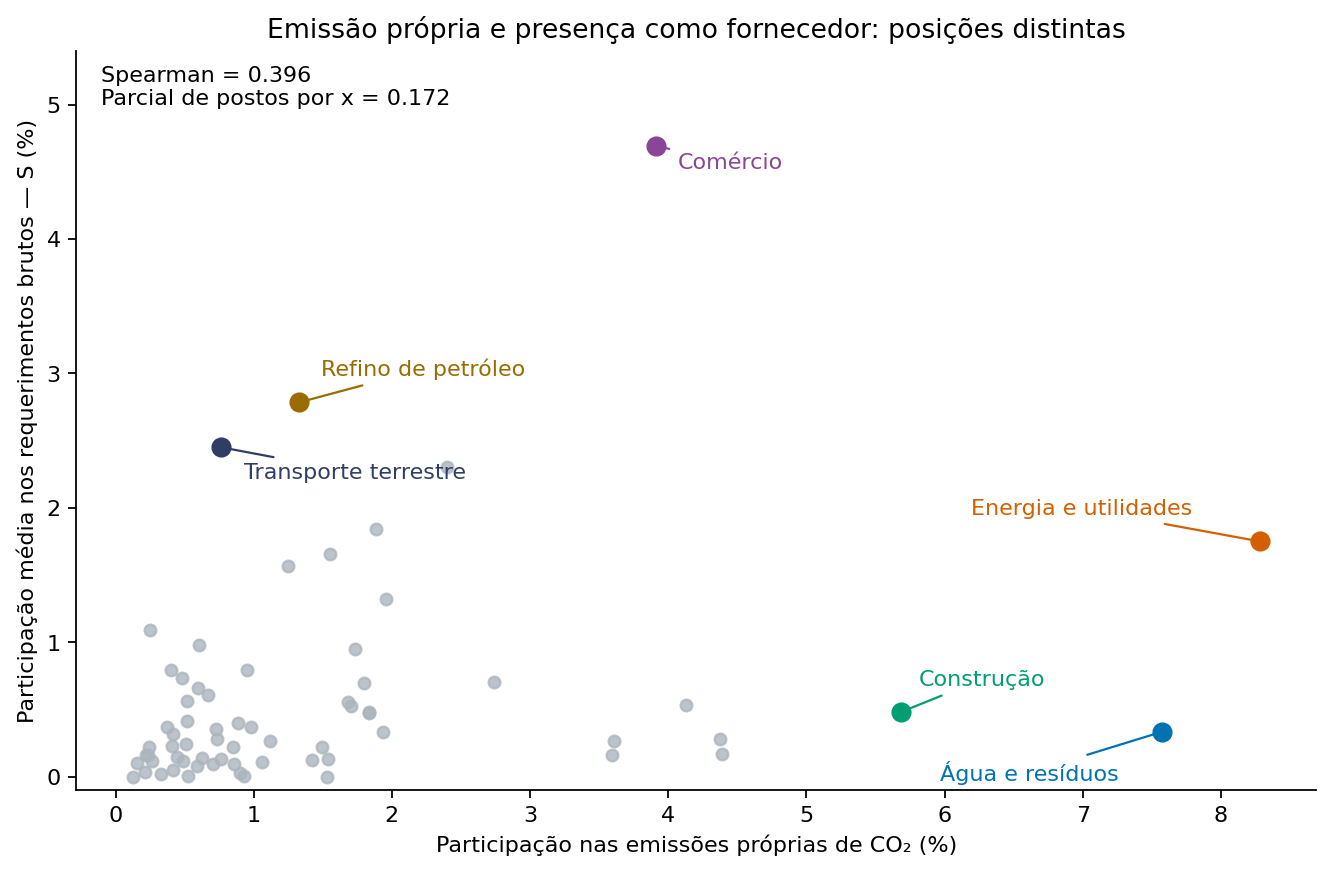

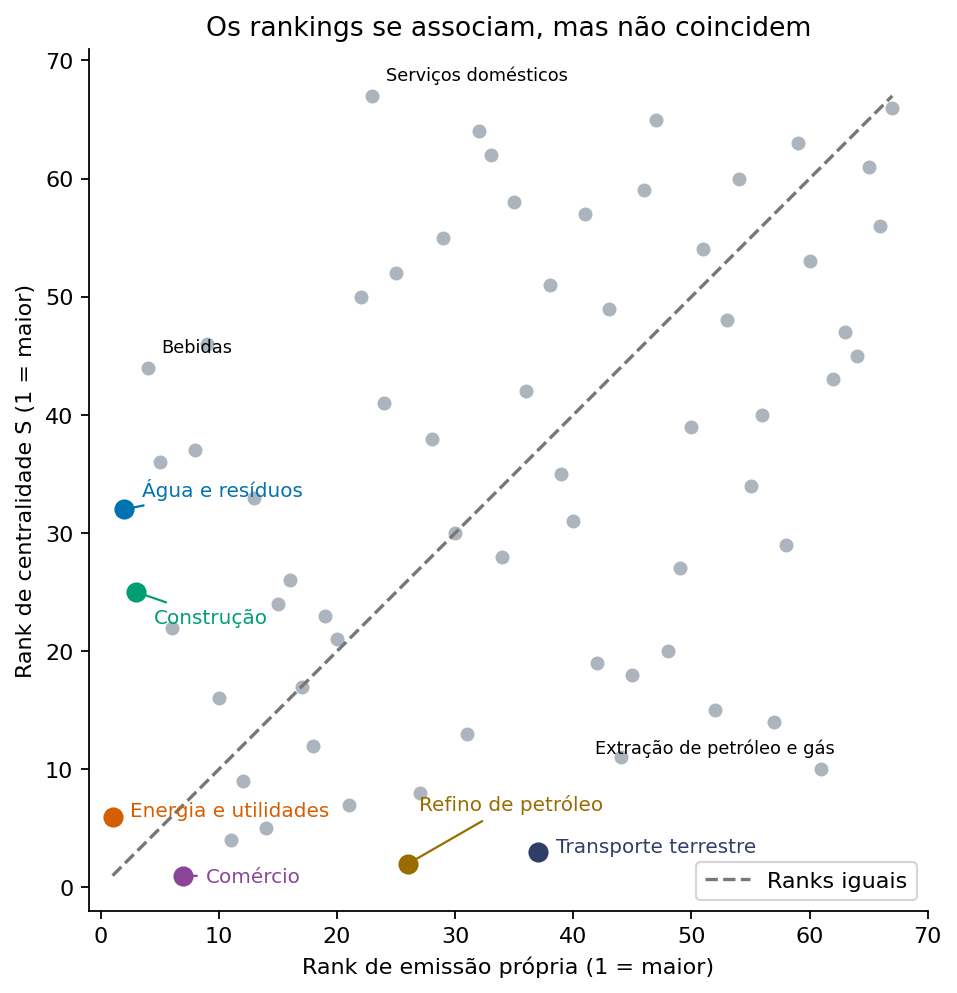

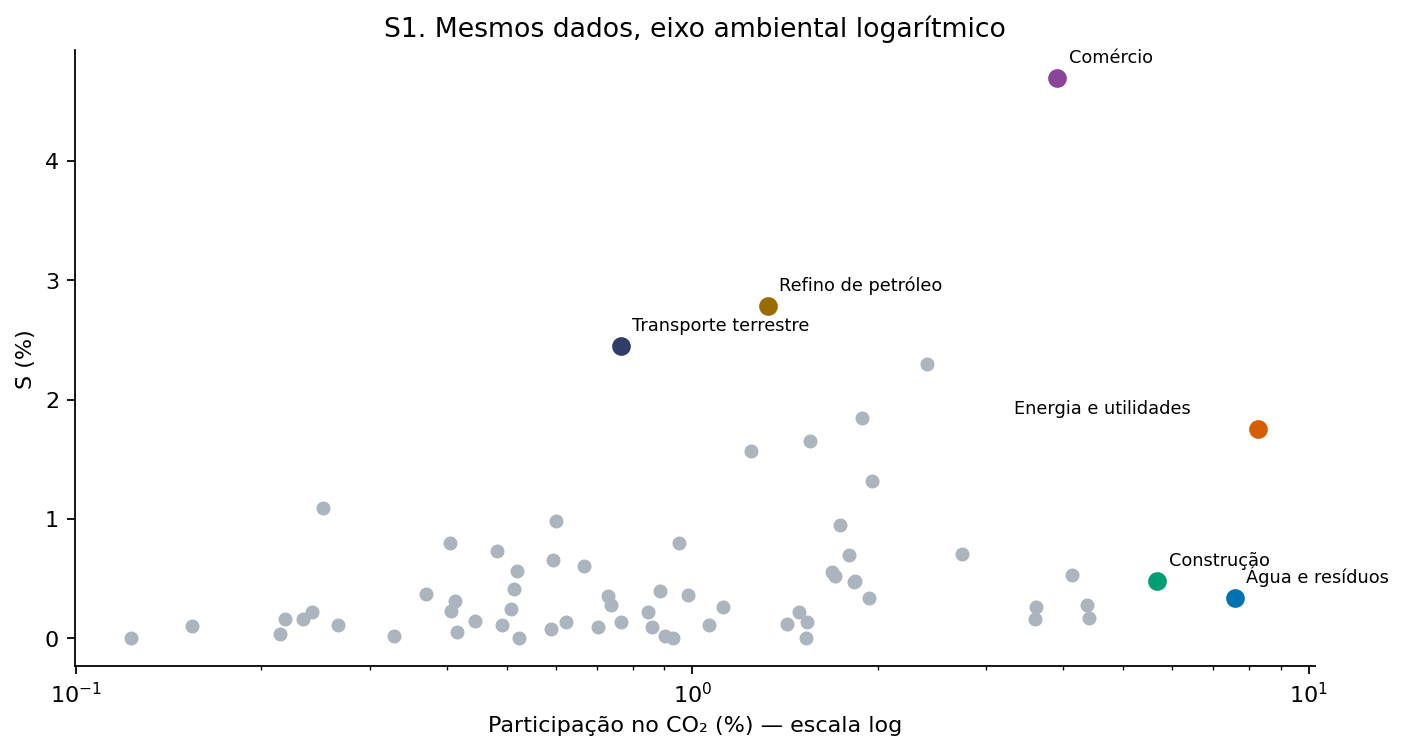

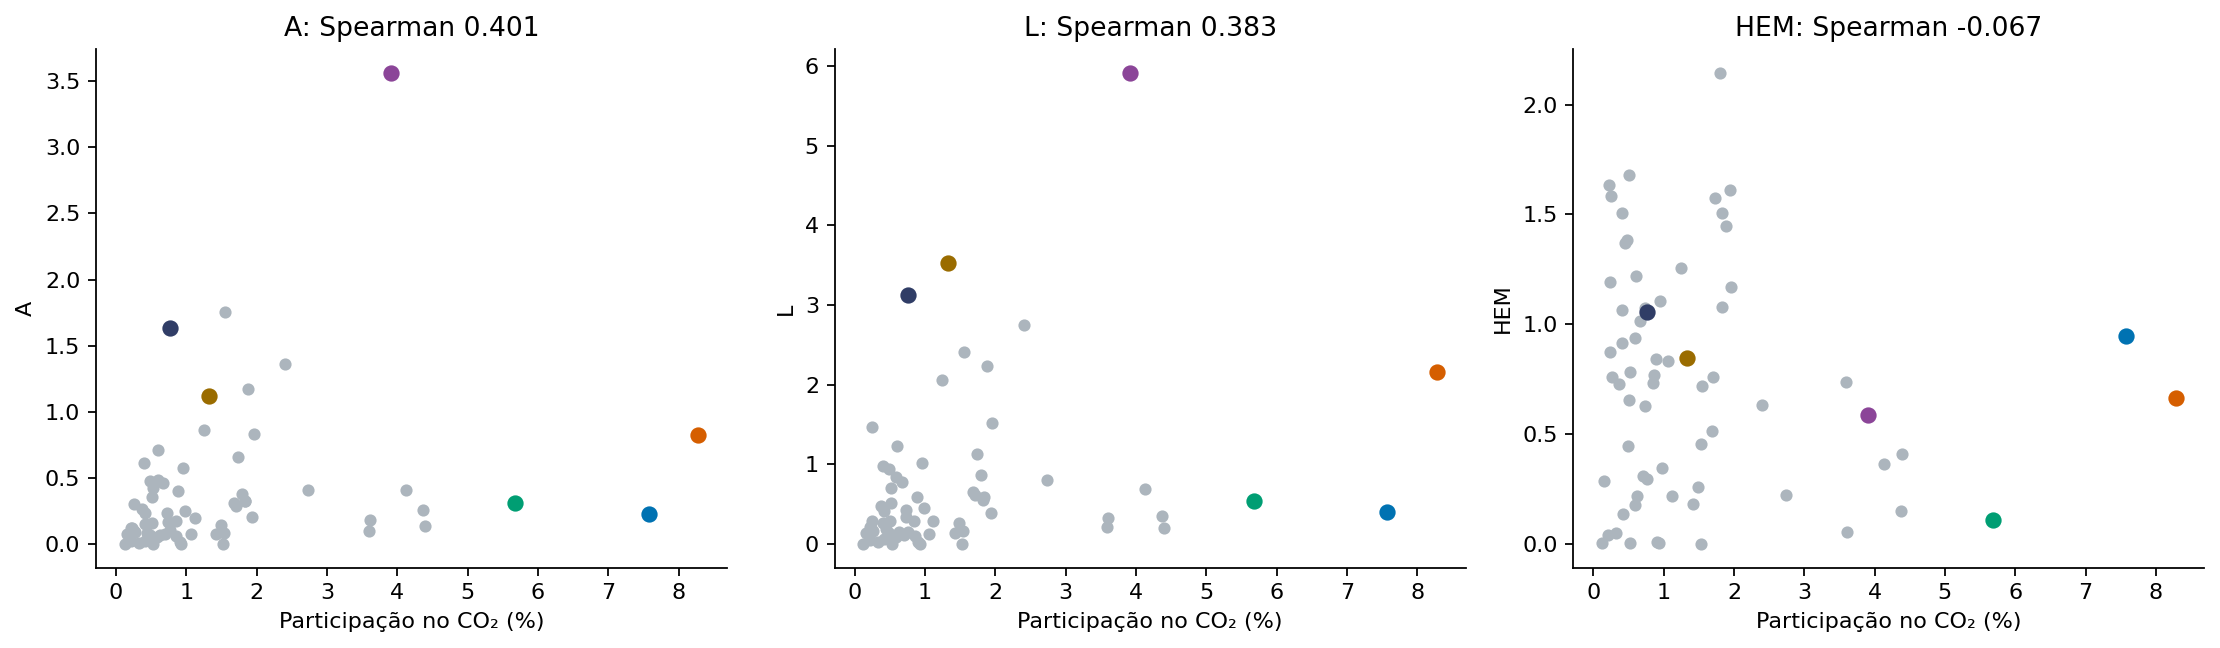

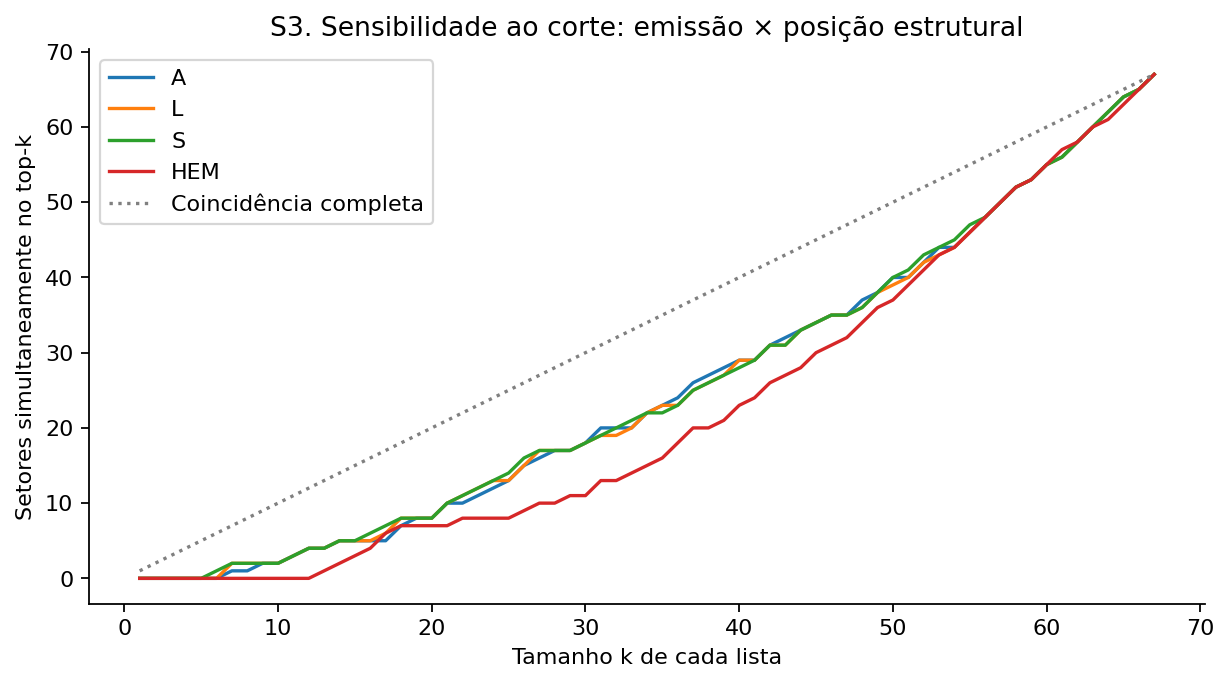

In [5]:
plt.rcParams.update({'font.size':10,'figure.dpi':120,'axes.spines.top':False,'axes.spines.right':False})
figuras={}
def salvar(fig,nome,legenda):
    fig.savefig(pasta/f'{nome}.png',dpi=160,bbox_inches='tight')
    fig.savefig(pasta/f'{nome}.svg',bbox_inches='tight')
    figuras[nome]=legenda
    display(Image(filename=str(pasta/f'{nome}.png')));plt.close(fig)

foco=list(rotulos)[:6]; cores={'3500':'#d55e00','3680':'#0072b2','4180':'#009e73',
                              '4580':'#8b4598','1991':'#9a6c00','4900':'#303d66'}
offsets={'3500':(-130,12),'3680':(-100,-22),'4180':(8,12),'4580':(10,-10),'1991':(10,12),'4900':(10,-14)}
fig,ax=plt.subplots(figsize=(10,6))
ax.scatter(100*e/e.sum(),100*metricas.S,color='#acb5bd',s=28,alpha=.8)
for sid in foco:
    px=setoriais.loc[sid,'participacao_e']*100;py=metricas.loc[sid,'S']*100
    ax.scatter(px,py,color=cores[sid],s=65,zorder=3)
    ax.annotate(rotulos[sid],(px,py),xytext=offsets[sid],textcoords='offset points',
                arrowprops={'arrowstyle':'-','color':cores[sid]},color=cores[sid])
ax.set(xlabel='Participação nas emissões próprias de CO₂ (%)',ylabel='Participação média nos requerimentos brutos — S̄ (%)',
       title='Emissão própria e presença como fornecedor: posições distintas')
ax.text(.02,.98,f'Spearman = {assoc.loc["S","spearman_e"]:.3f}\nParcial de postos por x = {assoc.loc["S","parcial_rank_x"]:.3f}',
         transform=ax.transAxes,va='top',bbox={'facecolor':'white','alpha':.9,'edgecolor':'none'})
ax.set_ylim(-.1,5.4)
salvar(fig,'figura_1_principal','S̄ exclui a cadeia final própria do numerador e preserva o denominador completo. Cada destino recebe o mesmo peso. Não mede essencialidade.')

fig,ax=plt.subplots(figsize=(9,7))
ax.scatter(rank_e,ranks.S,color='#acb5bd',s=28)
ax.plot([1,n],[1,n],ls='--',color='#777',label='Ranks iguais')
offset_rank={'3500':(8,0),'3680':(8,6),'4180':(8,-14),'4580':(10,-3),'1991':(5,24),'4900':(8,0)}
for sid in foco:
    ax.scatter(rank_e.loc[sid],ranks.loc[sid,'S'],s=65,color=cores[sid],zorder=4)
    ax.annotate(rotulos[sid],(rank_e.loc[sid],ranks.loc[sid,'S']),xytext=offset_rank[sid],textcoords='offset points',fontsize=9,
                arrowprops={'arrowstyle':'-','color':cores[sid]},color=cores[sid])
extras={'0680':'Extração de petróleo e gás','9700':'Serviços domésticos','1100':'Bebidas'}
for sid,nome in extras.items():
    ax.annotate(nome,(rank_e.loc[sid],ranks.loc[sid,'S']),xytext=(6,7),textcoords='offset points',fontsize=8,ha='right' if sid=='0680' else 'left')
ax.set(xlabel='Rank de emissão própria (1 = maior)',ylabel='Rank de centralidade S̄ (1 = maior)',
       title='Os rankings se associam, mas não coincidem',xlim=(-1,70),ylim=(-2,71))
ax.legend(loc='lower right'); ax.set_aspect('equal', adjustable='box')
salvar(fig,'figura_2_ranks','Distância vertical à diagonal mostra discordância de postos, não diferença percentual de magnitude. Extremos de discordância ficam nomeados; todos os setores entram no cálculo.')

fig,ax=plt.subplots(figsize=(10,5))
ax.scatter(100*e/e.sum(),100*metricas.S,color='#acb5bd',s=28)
for sid in foco:
    px=setoriais.loc[sid,'participacao_e']*100;py=100*metricas.loc[sid,'S']
    ax.scatter(px,py,color=cores[sid],s=55)
    ax.annotate(rotulos[sid],(px,py),xytext=(-110,7) if sid=='3500' else (5,7),textcoords='offset points',fontsize=8)
ax.set_xscale('log');ax.set(xlabel='Participação no CO₂ (%) — escala log',ylabel='S̄ (%)',title='S1. Mesmos dados, eixo ambiental logarítmico')
salvar(fig,'suplemento_1_log','Somente o eixo ambiental muda. Não eliminamos serviços domésticos, que têm S̄=0.')

fig,axs=plt.subplots(1,3,figsize=(14,4.2))
for ax,met in zip(axs,['A','L','HEM']):
    ax.scatter(100*e/e.sum(),metricas[met],s=20,color='#acb5bd')
    for sid in foco:
        ax.scatter(setoriais.loc[sid,'participacao_e']*100,metricas.loc[sid,met],color=cores[sid],s=40)
    ax.set(xlabel='Participação no CO₂ (%)',ylabel=met,title=f'{met}: Spearman {assoc.loc[met,"spearman_e"]:.3f}')
fig.tight_layout();salvar(fig,'suplemento_2_alternativas','Mesmas seis cores da figura principal. HEM usa efeito nos demais dividido pelo output do setor extraído; tem unidade e pergunta diferentes de S.')

fig,ax=plt.subplots(figsize=(9,4.5))
for met in metricas:
    c=curvas.query('cenario == "2015" and metrica == @met')
    ax.plot(c.k,c.intersecao,label=met)
ax.plot([1,n],[1,n],':',color='gray',label='Coincidência completa')
ax.set(xlabel='Tamanho k de cada lista',ylabel='Setores simultaneamente no top-k',title='S3. Sensibilidade ao corte: emissão × posição estrutural');ax.legend()
salvar(fig,'suplemento_3_cortes','Curva completa, sem definir uma fronteira arbitrária entre alto e baixo. A lista HEM se altera substancialmente após normalizar pelo tamanho da origem.')

## 6. Veredito adversarial e apresentação final

**P1 — fortemente sustentada nesta base:** emissão e centralidade de fornecedor não têm rankings coincidentes.
Isso não significa independência: a associação positiva é moderada na família A/L/S. HEM normalizada não a reforça,
mas também não aproxima os rankings ambientais dos estruturais.

**P2 — sustentada com ressalvas:** a associação positiva da família A/L/S enfraquece ao considerar x,
inclusive em cenários ambientais e exclusões de observações. Não desaparece; sua magnitude residual depende da
forma funcional. HEM normalizada não tem associação bruta positiva relevante a explicar. “Explicada” significa
associação estatística condicionada, não mecanismo causal identificado.

**P3 — frágil como afirmação independente da métrica:** Energia combina rank emissor 1 e ranks 9/7/6 em A/L/S,
mas rank 37 em HEM externa por unidade de output. Comércio é outro caso inequívoco de sobreposição em A/L/S,
com rank ambiental 5/7/8 nos cenários e rank estrutural 1. Não há evidência de excepcionalidade exclusiva de Energia.
Sua presença na fronteira de Pareto não basta: o máximo ambiental entra nela por construção.

Escolha final: **S principal; A e HEM normalizada como duas robustezes**, com a divergência desta última explicitada.
L fica no suplemento por redundância, não por resultado desfavorável. HEM absoluta é apresentada como
sensibilidade da unidade da mesma extração, não como confirmação adicional. A formulação ampla de “centralidade
sistêmica invariável” é abandonada. A afirmação restrita a presença monetária média nas cadeias sobrevive.

Esta é a qualificação da história testada, não busca de uma história nova. Não introduzimos uma nova tipologia.

In [6]:
def tabela(df):
    if isinstance(df,pd.Series):df=df.to_frame('valor')
    return '<div class="tabela">'+df.to_html(float_format=lambda z:f'{z:,.4f}',border=0,escape=True)+'</div>'

def figura(nome):
    png=base64.b64encode((pasta/f'{nome}.png').read_bytes()).decode()
    return f'<figure><img src="data:image/png;base64,{png}" alt="{html.escape(figuras[nome])}"><figcaption>{html.escape(figuras[nome])}</figcaption></figure>'

def secao(k,titulo,texto):
    return f'<section id="s{k}"><h2>{k}. {titulo}</h2>{texto}</section>'

status=pd.DataFrame([
 ('P1','Fortemente sustentada, condicional à base','Rankings diferem em A/L/S e HEM. Não implica independência: A/L/S têm associação positiva moderada com e.'),
 ('P2','Sustentada com ressalvas','Atenuação estável para A/L/S após considerar x. Associação residual não nula e dependente da forma funcional; HEM normalizada não tem relação bruta positiva relevante.'),
 ('P3','Frágil na formulação independente da métrica','Energia é alta em A/L/S, mas 37ª na HEM por x. Comércio também combina posições altas em todos os cenários. Pareto não certifica centralidade alta.')
],columns=['proposicao','avaliacao','razao']).set_index('proposicao')
loo=influencia[influencia.exclusao.str.startswith('LOO_')].groupby('metrica')[['rho','parcial_x']].agg(['min','max'])
delta=abs(rank_e-ranks.S)
top10=[nomes.loc[s] for s in ids[(rank_e<=10)&(ranks.S<=10)]]
comuns10=ids[(ranks<=10).all(axis=1)].tolist()
nomes_nucleo=', '.join(nomes.loc[comuns10]) if comuns10 else 'nenhum'
cenS=cenarios_assoc.query('metrica == "S"')
resid_rank=setoriais.rank_residuo_logS_logx
diag=pd.DataFrame({'setor':nomes,'Lii':np.diag(L),'Sii':np.diag(S),
                   'Sbar':metricas.S,'Sbar_sem_den_proprio':variantes.condicional_outras_origens},index=ids)
amostra_variantes=variantes.rank(ascending=False).loc[list(rotulos)]
auditoria=pd.Series({'n':n,'emissoes_Gg':e.sum(),'erro_hem_max':erro_hem,
    'erro_S_ajuste_negativo':erro_negativo,'mediana_desvio_rank_e_S':delta.median(),
    'media_desvio_rank_e_S':delta.mean(),'rho_gamma_x':rho(gamma,x),
    'R2_logS_logx':r2_tamanho,'beta_logS_logx':beta[1]})

partes=[]
partes.append(secao(1,'Hipótese provisória','''
<p>Testamos se emissão própria e posição produtiva como fornecedor são dimensões distintas; se a associação
entre elas se atenua ao considerar o tamanho econômico; e se Energia constitui um caso especialmente claro de
posição elevada nas duas dimensões. A tarefa foi refutar ou qualificar essa interpretação usando as alternativas
próximas da exploração anterior. Não repetimos centralidades distantes da pergunta.</p>
<div class="destaque"><b>Decisão:</b> a divergência dos rankings e a atenuação por tamanho resistem na família A/L/S.
A afirmação irrestrita sobre a centralidade de Energia não sobrevive: sua posição depende da normalização da HEM.
Comércio também é uma exceção importante. O núcleo publicável deve nomear a dimensão de centralidade que mede.</div>
<p>A base já foi explorada. Trata-se de validação interna e adversarial, não de teste confirmatório em dados
independentes. Critérios, resultados favoráveis e contraexemplos ficam documentados.</p>'''))
partes.append(secao(2,'Métrica ambiental',f'''
<p><b>eᵢ=γᵢxᵢ</b> e <b>sᵢᵉ=eᵢ/Σₖeₖ</b>. x é produção bruta em R$ milhões e γ é intensidade direta
em Gg CO₂/R$ milhão. O total central é {e.sum()/1000:.3f} Mt CO₂ estimados; não é um inventário observado
de todos os GEE. H=diag(γ)L é intensidade incorporada, P=Hdiag(y) é atribuição aos destinos finais e R é composição
ambiental: nenhum deles substitui e como variável principal. Conferimos A/L/S/H/R/P e e contra a exploração anterior.</p>
<p>Os coeficientes 2011/2018 de Sanguinet e Azzoni são interpolados por γ2015=(3γ2011+4γ2018)/7.
Persistem arredondamento, harmonização setorial e incompatibilidade de preços ainda não resolvida entre a fonte
e a MIP. Deflator comum não altera ranks; ajustes setoriais podem alterar emissões e comparações monetárias.
Este exercício não valida empiricamente a fonte ambiental.</p>
<p>Concentração é contexto: top5={contexto.loc['Emissões próprias e','top5']:.1%},
top10={contexto.loc['Emissões próprias e','top10']:.1%}, Gini emissor
{contexto.loc['Emissões próprias e','gini']:.3f}, versus {contexto.loc['Produção bruta x','gini']:.3f} para x.
Não parece excepcionalmente maior que a concentração econômica. O HHI inverte ligeiramente com γ2018,
conforme a exploração já publicada; não promovemos essa comparação a resultado principal.</p>'''))
partes.append(secao(3,'Métrica estrutural principal','''
<p>De x=Ax+y decorre L=(I−A)⁻¹. Lᵢⱼ é produção bruta de i requerida por uma unidade monetária de demanda
final de j. <b>Linha é fornecedor; coluna é destino final.</b> λⱼ=ΣₖLₖⱼ agrega os requerimentos monetários
de diferentes etapas; não é o valor adicionado nem o preço final, pois a produção intermediária aparece em etapas sucessivas.</p>
<p><b>Sᵢⱼ=Lᵢⱼ/λⱼ</b>, com ΣᵢSᵢⱼ=1, é a participação de i nesse requerimento agregado.
<b>S̄ᵢ=Σⱼ≠ᵢSᵢⱼ/(n−1)</b> é a média entre as outras 66 cadeias. Chamamos essa medida de
<em>presença monetária média como fornecedor em cadeias padronizadas</em>. Ela não mede número de destinos,
essencialidade ou impossibilidade de substituição.</p>
<p>A demanda de cada setor tem peso igual para não incorporar seu volume observado à pergunta principal.
Essa opção valoriza igualmente destinos pequenos e grandes e depende da classificação setorial. Não é uma média
ponderada de perda econômica real. Mediana e ponderação por output do destino desafiam essa escolha no suplemento.</p>
<p>O destino próprio sai do numerador; o próprio fornecedor de cada destino permanece no denominador λⱼ.
Retirar Lⱼⱼ do denominador condiciona a participação às outras origens. Retirar somente a identidade mantém
circuitos de retorno. Essas alternativas foram conferidas e não confundidas com a definição principal.</p>'''))
partes.append(secao(4,'Alternativas próximas e uma definição de HEM','''
<p><b>A:</b> soma fora da diagonal, Σⱼ≠ᵢAᵢⱼ, compara requerimentos diretos por unidades de produção dos
compradores. <b>L:</b> Σⱼ≠ᵢLᵢⱼ incorpora todos os caminhos por unidades de demanda final, sem a normalização λⱼ.
Nenhuma soma prevê uma ruptura de oferta.</p>
<p><b>HEM escolhida:</b> extração completa no fechamento de alocação Ghosh, apropriada ao contraste de
encadeamentos para frente. B=diag(x)⁻¹Z e G=(I−B)⁻¹=diag(x)⁻¹Ldiag(x). Seja r=x−Zᵀ1: é o fechamento
primário do sistema doméstico e inclui importações, não somente VAB. Removemos a linha/coluna i de B e rᵢ;
mantemos r₋ᵢ e a alocação entre os setores restantes. x*₋ᵢᵀ=r₋ᵢᵀ(I−B₋ᵢ,₋ᵢ)⁻¹.</p>
<p>Separadamente, a perda própria é xᵢ. Nos demais, Δxⱼ⁽ⁱ⁾=xᵢGᵢⱼ/Gᵢᵢ, j≠i. O efeito externo absoluto
é <b>Fᵢ=Σⱼ≠ᵢΔxⱼ⁽ⁱ⁾</b>. Para impedir que a robustez seja apenas uma comparação de escala, usamos
<b>hᵢ=Fᵢ/xᵢ</b>. F e h são unidades distintas da <em>mesma extração</em>, não duas definições de remoção.
Não confundimos essa medida externa com fórmulas que incluem o efeito próprio ou usam extração parcial.</p>
<p>A escolha se apoia na família de extrações de encadeamentos para frente de
<a href="https://doi.org/10.1080/09535319300000017">Dietzenbacher, van der Linden e Steenge (1993)</a>
e na <a href="https://www.iioa.org/conferences/13th/files/Lahr%26MillerExtrractionTaxonomy.pdf">taxonomia de Miller e Lahr</a>.
Como enfatiza <a href="https://doi.org/10.1111/j.1467-9787.1988.tb01208.x">Oosterhaven (1988)</a>,
o uso descritivo de encadeamentos não autoriza previsão causal de escassez.
Aqui a normalização externa é declarada e validada por solução direta dos 67 subsistemas.</p>
<p>Algebricamente hᵢ=Σⱼ≠ᵢLᵢⱼxⱼ/(xᵢLᵢᵢ). A diferença em relação a S envolve peso dos destinos,
escala do fornecedor e retorno próprio. É um teste severo de universalidade da narrativa, não uma medida
idêntica com outro nome. Não usamos extração Leontief de demanda para representar o mesmo papel de fornecedor.</p>'''))
partes.append(secao(5,'Validação da centralidade',f'''
<p>Há convergência muito forte dentro da família A/L/S: ρ(A,L)={convergencia.loc['A','L']:.3f},
ρ(A,S)={convergencia.loc['A','S']:.3f} e ρ(L,S)={convergencia.loc['L','S']:.3f}.
Os top10 de L e S coincidem; A compartilha nove deles. Isso mostra estabilidade ao encadeamento e à normalização,
<b>não três evidências independentes</b>.</p>
<p>Com HEM por x, ρ(S,h)={convergencia.loc['S','HEM']:.3f}; apenas dois dos top10 de S também estão
no top10 de h. A intersecção dos top10 das quatro medidas contém: {html.escape(nomes_nucleo)}.
No top20 simultâneo das quatro medidas há {int((ranks<=20).all(axis=1).sum())} setores. A extensão do núcleo comum depende do corte; não há equivalência entre as listas.</p>
<p>A perda externa absoluta F concorda muito mais com S (ρ={comparacao_variantes.loc['HEM_absoluta','rho_com_S']:.3f}).
Reportamos esse resultado favorável, mas ele não cancela o contraexemplo normalizado. A narrativa muda de
“peso externo total” para “encadeamento externo por unidade do setor” quando dividimos por x.</p>
<p>Esta é a <b>única tabela setorial principal</b>. HEM significa h=F/x; o rank L é mantido aqui para
permitir a auditoria da convergência e não é uma terceira robustez na metodologia final.</p>'''+tabela(principal)))
partes.append(secao(6,'Emissão versus centralidade',f'''
<p>Emissão e S têm Spearman {assoc.loc['S','spearman_e']:.3f}; Pearson(log e,S)={assoc.loc['S','pearson_loge_C']:.3f}.
Para A/L, Spearman é {assoc.loc['A','spearman_e']:.3f}/{assoc.loc['L','spearman_e']:.3f}.
São associações positivas moderadas, incompatíveis tanto com equivalência dos rankings quanto com independência.</p>
<p>A mediana da distância absoluta entre ranks e e S é {delta.median():.0f} posições; a média é {delta.mean():.1f}.
No top10 comum aparecem Energia e Comércio; a curva de todos os cortes está no suplemento. Na HEM normalizada,
Spearman(e,h)={assoc.loc['HEM','spearman_e']:.3f} e nenhum setor compartilha os top10 ambiental e estrutural.</p>'''+
figura('figura_1_principal')+figura('figura_2_ranks')+'''
<p>Os maiores desvios incluem extração de petróleo/gás e manutenção de máquinas, que sobem no ranking produtivo,
e serviços domésticos e bebidas, que sobem no ambiental. A tabela completa de desvios fica no suplemento.
Serviços domésticos são estruturalmente isolados nesta MIP e não foram apagados do gráfico para melhorar a correlação.</p>'''))
partes.append(secao(7,'Papel do tamanho econômico',f'''
<p>Para S, a correlação parcial de postos condicionada a x é {assoc.loc['S','parcial_rank_x']:.3f}, frente a
{assoc.loc['S','spearman_e']:.3f} bruta. Em A/L, fica em {assoc.loc['A','parcial_rank_x']:.3f}/
{assoc.loc['L','parcial_rank_x']:.3f}. A associação enfraquece, mas não desaparece. Não interpretamos a diferença
como porcentagem causal explicada pelo tamanho.</p>
<p>No ajuste log–log, que exclui o setor com S=0 sem adicionar constante, a associação bruta é
{assoc.loc['S','pearson_loge_logC']:.3f} e a correlação residual após controlar log x é
{assoc.loc['S','parcial_log_x']:.3f} (66 setores). A associação residual não é invariavelmente “quase zero”:
sua magnitude depende da forma funcional. O suplemento usa os mesmos casos para comparar bruto e parcial.</p>
<p>Spearman(S,x)={assoc.loc['S','spearman_x']:.3f}, Spearman(S,γ)={assoc.loc['S','spearman_gamma']:.3f};
γ e x têm ρ={rho(gamma,x):.3f}. Há compensação entre escala e intensidade. e=γx, ou log e=log γ+log x,
explica por que volume e intensidade não devem receber a mesma interpretação.</p>
<p>Excluir Energia e Comércio conjuntamente mantém Spearman(e,S) em
{influencia.query('exclusao=="sem_energia_comercio" and metrica=="S"').rho.iloc[0]:.3f} e parcial em
{influencia.query('exclusao=="sem_energia_comercio" and metrica=="S"').parcial_x.iloc[0]:.3f}.
Exclusões uma a uma dão correlação bruta {loo.loc['S',('rho','min')]:.3f}–{loo.loc['S',('rho','max')]:.3f}
e parcial {loo.loc['S',('parcial_x','min')]:.3f}–{loo.loc['S',('parcial_x','max')]:.3f}.
A atenuação não depende de um único ponto, mas tampouco identifica causalidade.</p>
<p>O tamanho sozinho explica {r2_tamanho:.1%} da variância de log S no ajuste exploratório. Portanto,
não cabe concluir que a centralidade de todos os grandes setores seja apenas tamanho.
HEM normalizada não tem associação bruta positiva a ser “explicada”; sua correlação parcial de ranks é
{assoc.loc['HEM','parcial_rank_x']:.3f}. A proposição P2 deve nomear a família A/L/S.</p>'''))
partes.append(secao(8,'Contrastes setoriais',f'''
<p><b>Energia elétrica, gás natural e outras utilidades (3500).</b> {setoriais.loc['3500','participacao_e']:.2%}
do CO₂ central, rank 1 ambiental e 9/7/6 em A/L/S. É 10ª em output e em intensidade; ambos contribuem.
Em HEM externa absoluta, rank 10; por x, rank 37. A perda externa por unidade é {h[list(ids).index('3500')]:.3f},
não uma previsão de paralisação. Não isolamos eletricidade das demais atividades agregadas nesse código.</p>
<p><b>Água/esgoto/resíduos (3680).</b> {setoriais.loc['3680','participacao_e']:.2%} das emissões, rank 2;
rank de output 41 e intensidade 1. Seus ranks A/L/S são 34/33/32 e h é 22. O contraste ambiental–produtivo
permanece; decorre nesta base sobretudo da intensidade elevada, cuja plausibilidade requer validação externa.</p>
<p><b>Construção (4180).</b> Rank 3 ambiental e de output; intensidade em posição intermediária.
Ranks 25/27/25 em A/L/S e 59 em h. A emissão elevada não a torna fornecedora dominante; o setor atende em grande
parte sua própria demanda final. O resíduo de log S condicionado a log x é negativo, em posto
{resid_rank.loc['4180']:.0f} entre 66 casos.</p>
<p><b>Comércio (4580).</b> Rank 7 ambiental, rank 1 em output e A/L/S; sua intensidade é relativamente baixa.
É um segundo caso importante de sobreposição, não detalhe a omitir para destacar Energia. Após ajustar log S
por log x, seu resíduo ainda está em {resid_rank.loc['4580']:.0f}º: a posição não é inteiramente explicada pelo tamanho.
Mas h o coloca em 41º, versus 1º em F. Tamanho contribui sem esgotar o papel estrutural.</p>
<p><b>Refino de petróleo/coquerias (1991).</b> Rank 26 ambiental e 6/2/2 em A/L/S; 6º em output,
intensidade baixa na base. Resíduo de log S condicionado a tamanho em {resid_rank.loc['1991']:.0f}º.
HEM absoluta: 4º; por x: 26º. A alta presença nas cadeias unitárias sobrevive; a posição elevada em toda
normalização não. Emissão própria do refino não equivale a todo o impacto do uso dos combustíveis.</p>
<p><b>Transporte terrestre (4900).</b> Rank 37 ambiental e 3 em A/L/S; output 7 e intensidade em posto baixo.
Resíduo condicionado a tamanho em {resid_rank.loc['4900']:.0f}º; F em 3º e h em 20º. O contraste existe nos dados,
mas não deve ser convertido em afirmação geral de que transporte emite pouco fora desta alocação setorial.</p>
<p><b>Outros casos, sem criar uma tipologia.</b> Jurídicas/contábeis/consultoria (6980) aparece no top10 das
quatro centralidades, porém é 14º emissor; serviços administrativos (7880) é 12º emissor, 9º em S e 15º em h.
Esses exemplos mostram que “poucos” e “alto” dependem do corte. A tabela e a curva contínua preservam essa informação.</p>'''))
partes.append(secao(9,'Robustez ambiental',f'''
<p>Os coeficientes de 2011 e 2018 aplicados a x2015 mantêm correlação de ranks emissivos superior a 0,98
com o cenário central. Para S, Spearman(e,S) varia de {cenS.spearman_e.min():.3f} a {cenS.spearman_e.max():.3f};
a parcial por x varia de {cenS.parcial_rank_x.min():.3f} a {cenS.parcial_rank_x.max():.3f}.
O resultado principal não depende da interpolação exata entre esses extremos.</p>
<p>Energia é 1ª emissora nos três cenários. Comércio ocupa 5º, 7º e 8º. A fronteira de Pareto de e×S
contém somente Energia e Comércio em todos eles; isso se repete em A/L. Contudo, o maior emissor é não dominado
por construção. O argumento de posição conjunta precisa também de ranks estruturais altos, não apenas da fronteira.</p>
<p>Em 2015 o menor corte que inclui Energia em ambas as listas é top6 para S, e Comércio top7.
Com γ2011, Comércio entra já no top5, antes de Energia no top6. “Energia é inequivocamente o caso mais claro”
não é uma ordenação universal. Em h, seriam necessários top37 para Energia e top41 para Comércio.</p>
<p>Essas são apenas alternativas dentro da mesma fonte. Não cobrem erro de harmonização, preços setoriais,
emissões omitidas ou uma nova base ambiental independente. Não repetimos centenas de cenários da exploração geral.</p>'''))
falsificacao=pd.DataFrame([
 ('Ranks se aproximam com outra medida','A/L/S quase redundantes, mas diferem de e; h também não aproxima o ranking emissor.','P1 resiste; não afirmar independência.'),
 ('O resultado depende de destino com peso igual','Mediana, peso por x e denominadores alternativos preservam o contraste principal; mudam magnitudes.','S defensável para a pergunta padronizada, não único estimando.'),
 ('A associação é um artefato de dois pontos','Exclusão de Energia/Comércio, top5 output e leave-one-out preserva atenuação para S.','P2 resiste dentro de A/L/S.'),
 ('Controle de tamanho elimina toda relação','Parcial por ranks ≈0,17; log–log ≈0,27. Comércio/Refino/Transporte ainda têm resíduos positivos.','Eliminar a frase “tudo é tamanho”.'),
 ('Energia lidera em toda noção de fornecedor','h coloca Energia em 37º e Comércio em 41º; F coloca em 10º e 1º.','P3 irrestrita falha. Não descartar h por contrariar a história.'),
 ('Energia é a única exceção','Comércio é 1º fornecedor e 5º–8º emissor nos cenários.','Excepcionalidade exclusiva falha.'),
 ('Pareto prova posição simultaneamente alta','O maior emissor entra na fronteira independentemente do rank estrutural.','Pareto sozinho é insuficiente.'),
 ('Novo ano de coeficientes derruba a narrativa','γ2011/γ2018 preservam os contrastes A/L/S e o contraexemplo h.','Robusto à fonte existente; não valida emissões observadas.')
],columns=['tentativa','resultado','consequencia'])
partes.append(secao(10,'Tentativas de falsificação','''
<p>Avaliamos explicitamente convergência estrutural, sensibilidade à diagonal e aos pesos dos destinos,
influência de observações grandes, forma funcional do controle de tamanho, normalização da extração,
coeficientes ambientais e o caráter quase tautológico da fronteira de Pareto nos extremos.
O registro completo de cada tentativa e sua consequência está no suplemento.</p>
<p><b>P1: fortemente sustentada, condicional à base.</b> Há discordância substantiva, não independência.
<b>P2: sustentada com ressalvas.</b> Atenuação em A/L/S, sem interpretação causal nem desaparecimento total.
<b>P3: frágil na versão independente da métrica.</b> Energia é destaque na família A/L/S e em F, mas não em h;
Comércio também deve integrar a conclusão. Os resultados desfavoráveis não foram deslocados para fora do argumento.</p>'''))
partes.append(secao(11,'Resultado que sobreviveu','''
<p>Na MIP2015 com estas intensidades, o ranking de emissão própria não coincide com a presença monetária
média de fornecedor nas cadeias dos demais setores. A associação é positiva e moderada; enfraquece, sem
desaparecer, ao considerar o tamanho econômico. Energia e Comércio combinam posições elevadas em emissão e
presença nas cadeias na família A/L/S, com estabilidade aos cenários ambientais existentes.</p>
<p>Esta afirmação delimitada pode ser o núcleo empírico. Sua robustez não autoriza substituir “presença média
nas cadeias” por “importância sistêmica”, nem extrapolar para todos os GEE ou uma base independente.</p>'''))
partes.append(secao(12,'Resultado que não sobreviveu','''
<ul><li>Energia é central em qualquer definição razoável de importância intersetorial: h é um contraexemplo.</li>
<li>Energia é a única exceção, ou sempre a exceção mais evidente: Comércio também se destaca e pode entrar
antes em cortes conjuntos sob γ2011.</li>
<li>A/L/S constituem três confirmações independentes: são quase redundantes.</li>
<li>A centralidade é só tamanho, ou a associação residual é zero: resíduos e especificações log–log contradizem isso.</li>
<li>“Poucos” define um grupo natural fixo: intersecções aumentam com o corte; mantemos ranks contínuos.</li>
<li>Presença na fronteira de Pareto prova centralidade alta: o máximo emissor entra por construção.</li>
<li>Um cenário de extração demonstra essencialidade ou perda causal de produção: faltam as hipóteses e dados necessários.</li></ul>'''))
partes.append(secao(13,'Pergunta de pesquisa final','''
<p>A formulação “Os setores responsáveis pelas maiores emissões ocupam também posições centrais como
fornecedores?” é acessível, mas exige definir “maiores” e “centrais” e convida a uma resposta binária que esconde
a associação moderada. “Qual é a relação entre participação nas emissões e centralidade como fornecedor?”
é mais adequada, desde que a centralidade seja operacionalizada antes de interpretar resultados.</p>
<blockquote>Qual é a relação entre a participação setorial nas emissões próprias de CO₂ e a presença monetária
média dos setores como fornecedores nas cadeias produtivas brasileiras de 2015, considerando o tamanho econômico?</blockquote>
<p>Essa pergunta é genuinamente de redes de produção: usa todos os caminhos em L e a distribuição relativa
dos requerimentos por origem e destino. Não necessita de um ranking causal de choques para ser relevante.</p>
<p><b>Versão enxuta final:</b> S como principal; A para contraste direto e h como robustez que delimita a
interpretação. Uma figura de emissão×S, uma figura de ranks e a tabela setorial desta página. L e F,
diagnósticos de pesos/diagonal, cenários detalhados e exclusões ficam no suplemento. Não adicionamos novos
indicadores para recuperar uma universalidade refutada.</p>'''))
partes.append(secao(14,'Hipóteses finais','''
<p><b>H1 revisada:</b> o ranking de emissões próprias difere substantivamente do ranking de presença monetária
média como fornecedor, embora exista associação positiva moderada; Energia e Comércio são casos de sobreposição
alta na família de requerimentos A/L/S. Essa sobreposição não é invariável à normalização de extração.</p>
<p><b>H2 revisada:</b> na família A/L/S, a associação entre volume emissor e posição como fornecedor se atenua
ao condicionar descritivamente pelo tamanho econômico, mas não desaparece em todas as formas funcionais.</p>
<p>Essas hipóteses são qualificações posteriores à exploração da mesma base. Para etapa confirmatória, fixar
as definições e validar em intensidades independentes ou outra matriz monetariamente compatível, sem escolher
nova especificação em função de seu resultado. “Explicada parcialmente” é uma descrição estatística, não causalidade.</p>'''))
partes.append(secao(15,'Conclusão','''
<p><b>Os setores que mais emitem são também os mais centrais?</b> Não de modo geral. Na definição principal
de presença nas cadeias, há associação moderada e discordâncias grandes de ranking. O tamanho econômico
contribui para a associação, sem explicá-la integralmente.</p>
<p><b>Quais são as principais exceções?</b> Energia e Comércio combinam posições altas em A/L/S e nos três
cenários de emissão. Energia combina escala e intensidade; Comércio, grande escala e fornecimento amplo.
Água/resíduos é grande emissor sobretudo por intensidade; Construção por escala, com presença mais baixa como
fornecedor. Refino e Transporte terrestre são fornecedores muito presentes, mas têm intensidades próprias baixas
nesta fonte. Esses contrastes permanecem condicionais à validade da alocação ambiental.</p>
<p><b>Limite decisivo:</b> Energia cai para 37º na extração externa por unidade de output. Portanto, a história
curta sobrevive apenas ao nomear a centralidade de requerimentos que utiliza; sua versão universal foi refutada.
“Centralidade produtiva” descreve presença; “dependência contábil” descreve requerimentos condicionais à tecnologia;
“essencialidade” exige ausência de substitutos; “importância sistêmica causal” exige um modelo identificado de choque.
Esta análise sustenta as duas primeiras em sentido contábil, não as duas últimas.</p>'''))

suplemento='<section id="suplemento"><h2>Material suplementar e reprodução</h2>'
suplemento+='''<p>Todas as tabelas abaixo estão também em CSV. A tabela HEM separa perda própria de efeito
externo; versões absoluta e normalizada pertencem à mesma extração. Rankings de intensidade com empates usam
posto médio. A cadeia de serviços domésticos não tem requerimentos externos; em normalizações condicionais
ela é indefinida e sai da média correspondente. Os números de casos ficam explícitos no código.</p>'''
suplementos={
 'S1 — Correlações ambiental, tamanho e intensidade':assoc,
 'S2 — Convergência de ranks estruturais':convergencia,
 'S3 — Sobreposição estrutural por corte':intersecoes,
 'S4 — Influência e exclusões, incluindo todos os leave-one-out':influencia,
 'S5 — Diagonal, denominador e pesos de destinos':comparacao_variantes,
 'S6 — Ranks nas variantes para setores destacados':amostra_variantes,
 'S7 — Cenários ambientais: associações':cenarios_assoc,
 'S8 — Cenários: fronteiras e estabilidade ambiental':resumo_cenarios,
 'S9 — Todos os ranks conjuntos e participação na fronteira':ranks_cenarios,
 'S10 — Setores: escala, intensidade, HEM e resíduos':setoriais,
 'S11 — Maiores desvios entre ranking ambiental e S':maiores_desvios[['nome','rank_e','rank_S','desvio_rank_e_menos_S']],
 'S12 — Tentativas de falsificação':falsificacao,
 'S13 — Veredito das proposições':status,
 'S14 — Auditoria numérica':auditoria}
for titulo,df in suplementos.items():
    suplemento+=f'<details><summary>{titulo}</summary>{tabela(df)}</details>'
for nome in ['suplemento_1_log','suplemento_2_alternativas','suplemento_3_cortes']:
    suplemento+=f'<details><summary>{nome}</summary>{figura(nome)}</details>'
suplemento+='''<h3>Fontes e definições</h3><ul>
<li>IBGE. MIP Brasil 2015, 67 atividades. Entradas e hashes em <code>raw/manifesto.csv</code>.</li>
<li><a href="https://doi.org/10.1016/j.rspp.2024.100015">Sanguinet e Azzoni (2024)</a>: coeficientes ambientais de origem.</li>
<li><a href="https://doi.org/10.1017/CBO9780511626982">Miller e Blair (2009), Input–Output Analysis</a>: requerimentos e encadeamentos.</li>
<li><a href="https://doi.org/10.1080/09535319300000017">Dietzenbacher, van der Linden e Steenge (1993), The Regional Extraction Method</a>: extração e direção dos encadeamentos.</li>
<li><a href="https://www.iioa.org/conferences/13th/files/Lahr%26MillerExtrractionTaxonomy.pdf">Miller e Lahr, taxonomia de extrações</a>: distinção entre definições de remoção.</li>
<li><a href="https://doi.org/10.1111/j.1467-9787.1988.tb01208.x">Oosterhaven (1988), On the Plausibility of the Supply-Driven Input-Output Model</a>: limite descritivo versus causal.</li></ul>
<p>Pesquisa metodológica adicional restrita à direção e à interpretação da HEM. A equação externa e sua
normalização são explicitadas e verificadas aqui; não alegamos que todas as fontes adotem a mesma normalização.</p>
<h3>Reproduzir</h3><p>Execute <code>validacao_emissao_centralidade_2015.ipynb</code> da raiz, em ordem.
O notebook confere as matrizes publicadas com a MIP bruta e regrava somente esta pasta de validação.
Os dados não fornecem elasticidades, estoques ou respostas a choques. Resultados de outros anos de coeficientes
mantêm sempre a economia de 2015 fixa. Nenhuma nova dependência foi adicionada.</p>'''
versoes={'Python':platform.python_version(),'numpy':np.__version__,'pandas':pd.__version__,
          'scipy':scipy.__version__,'matplotlib':matplotlib.__version__}
suplemento+=tabela(pd.Series(versoes))+'</section>'
css='''body{max-width:1080px;margin:auto;padding:32px;font:16px/1.65 system-ui,sans-serif;color:#203445;background:#fcfdff}
h1{font-size:2.2em;line-height:1.2}h2{color:#145b70;margin-top:2.7em;border-bottom:2px solid #cbdce5}h3{margin-top:2em}
p,li{max-width:100ch}a{color:#08638d}img{max-width:100%;height:auto}figure{margin:25px 0}figcaption{font-size:14px;color:#526573}
.destaque,blockquote{background:#eaf3f4;padding:20px;border-left:4px solid #157884;margin:24px 0}
.tabela{overflow:auto;max-height:650px;margin:20px 0}table{border-collapse:collapse;font-size:13px}th,td{padding:8px;text-align:left;border-bottom:1px solid #d9e2e9;vertical-align:top}th{background:#e9f1f6}
details{border:1px solid #c5d5e0;padding:12px;margin:15px 0}summary{cursor:pointer;font-weight:bold}nav{display:flex;flex-wrap:wrap;gap:13px}code{background:#edf1f4}
@media print{body{padding:0}img{max-height:85vh}.tabela{max-height:none}h2{break-after:avoid}}
'''
documento='<!doctype html><html lang="pt-BR"><head><meta charset="utf-8"><meta name="viewport" content="width=device-width, initial-scale=1"><title>Validação adversarial — emissão e centralidade, Brasil 2015</title><style>'+css+'</style></head><body>'
documento+='<h1>Emissão própria e centralidade de fornecedor</h1><p>Validação adversarial da interpretação • Brasil, MIP 2015</p><nav>'+''.join(f'<a href="#s{k}">{k}</a>' for k in range(1,16))+'<a href="#suplemento">Suplemento</a></nav>'
documento+=''.join(partes)+suplemento+'</body></html>'
(pasta/'relatorio.html').write_text(documento,encoding='utf8')
exports={'tabela_principal':principal,'associacoes':assoc,'convergencia_estrutural':convergencia,
    'sobreposicoes_estruturais':intersecoes,'influencia':influencia,'variantes_definicao':comparacao_variantes,
    'cenarios_associacoes':cenarios_assoc,'cenarios_ranks_pareto':ranks_cenarios,'curvas_topk':curvas,
    'cenarios_resumo':resumo_cenarios,'setores_completos':setoriais,'maiores_desvios':maiores_desvios,
    'tentativas_falsificacao':falsificacao,'veredito':status,'auditoria':auditoria,'diagonal':diag}
for nome,df in exports.items():df.to_csv(pasta/f'{nome}.csv',encoding='utf-8-sig')
entradas=['investigacao_redes_emissoes_2015.ipynb','docs/revisao_investigacao_2015.md','raw/manifesto.csv']
entradas += [str(anterior/f) for f in ['metricas_setoriais.csv','comparacoes_rankings.csv','cenarios_coeficientes.csv',
                                     'matriz_A.csv','matriz_L.csv','matriz_S.csv','matriz_H.csv','matriz_R.csv','matriz_P.csv']]
proveniencia={'versoes':versoes,'entradas_contexto_sha256':{f:hashlib.sha256(Path(f).read_bytes()).hexdigest() for f in entradas},
 'notebook':'validacao_emissao_centralidade_2015.ipynb','HEM':'extracao completa Ghosh; efeito externo F; principal F/x',
 'medida_principal':'S','robustez_final':['A','HEM externa por x'],'suplementar_redundante':'L'}
(pasta/'reproducibilidade.json').write_text(json.dumps(proveniencia,ensure_ascii=False,indent=2),encoding='utf8')
display(status)
print('Relatório autocontido:',pasta/'relatorio.html')

Relatório autocontido: outputs\validacao_emissao_centralidade_2015\relatorio.html


,avaliacao,razao
proposicao,,
P1,"Fortemente sustentada, condicional à base",Rankings diferem em A/L/S e HEM. Não implica independência: A/L/S têm associação positiva moderada com e.
P2,Sustentada com ressalvas,Atenuação estável para A/L/S após considerar x. Associação residual não nula e dependente da forma funcional; HEM normalizada não tem relação bruta positiva relevante.
P3,Frágil na formulação independente da métrica,"Energia é alta em A/L/S, mas 37ª na HEM por x. Comércio também combina posições altas em todos os cenários. Pareto não certifica centralidade alta."
